<a href="https://colab.research.google.com/github/vikranthrach/IIT-Patna--AI-and-ML-Course/blob/main/Batch2_Data_Cleaning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

In [ ]:
import pandas as pd
df = pd.read_csv("/content/used_cars_messy.csv")
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [ ]:
df.shape

(15661, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


In [ ]:
(df.isnull().sum() * 100) / len(df)

,0
Unnamed: 0,0.000000
car_name,0.000000
brand,0.000000
model,0.000000
vehicle_age,0.000000
km_driven,0.000000
seller_type,0.000000
fuel_type,0.000000
transmission_type,0.000000
mileage,8.205095


In [ ]:
df.duplicated().sum()

np.int64(169)

In [ ]:
df[df.duplicated(keep=False)].sort_values("car_name")

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4727,1809,Volkswagen Vento,Volkswagen,Vento,7,59000,Dealer,Petrol,Manual,15.04,1598.0,103.60,5.0,450000.0
9546,7646,Volkswagen Vento,Volkswagen,Vento,7,32000,Dealer,Diesel,Manual,NaN,1498.0,103.20,5.0,725000.0
10280,7646,Volkswagen Vento,Volkswagen,Vento,7,32000,Dealer,Diesel,Manual,NaN,1498.0,103.20,5.0,725000.0
911,18223,Volkswagen Vento,Volkswagen,Vento,10,69988,Dealer,Diesel,Manual,20.54,1598.0,103.60,5.0,349000.0


In [ ]:
169*2

338

In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,engine,max_power,seats,selling_price
count,15661.000000,15661.000000,13792.000000,14862.000000,15218.000000,1.550300e+04
mean,9808.189643,6.036843,1480.489342,100.513582,5.324418,1.032764e+06
std,5642.981540,3.015072,511.446057,42.854632,0.805993,1.607380e+07
min,0.000000,0.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4901.000000,4.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9858.000000,6.000000,1248.000000,88.500000,5.000000,5.550000e+05
75%,14666.000000,8.000000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,6592.000000,626.000000,9.000000,1.000000e+09


In [ ]:
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [ ]:
cat_cols = ["brand", "seller_type", "fuel_type", "transmission_type"]

for cat in cat_cols:
    unique_vals = df[cat].unique()
    print(f"\n{cat} ({len(unique_vals)} unique Values)")
    print(sorted(unique_vals))


brand (80 unique Values)
[' Audi', ' Audi ', ' BMW', ' BMW ', ' Datsun', ' Datsun ', ' Ferrari ', ' Ford', ' Ford ', ' Honda', ' Honda ', ' Hyundai', ' Hyundai ', ' ISUZU ', ' Land Rover', ' MG ', ' Mahindra', ' Mahindra ', ' Maruti', ' Maruti ', ' Mercedes-AMG ', ' Mercedes-Benz ', ' Mini ', ' Nissan ', ' Porsche', ' Renault', ' Renault ', ' Skoda', ' Skoda ', ' Tata', ' Tata ', ' Toyota', ' Toyota ', ' Volkswagen', ' Volkswagen ', 'Audi', 'Audi ', 'BMW', 'BMW ', 'Bentley', 'Datsun', 'Datsun ', 'Force', 'Ford', 'Ford ', 'Honda', 'Honda ', 'Hyundai', 'Hyundai ', 'ISUZU', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG', 'Mahindra', 'Mahindra ', 'Maruti', 'Maruti ', 'Maserati', 'Mercedes-Benz', 'Mercedes-Benz ', 'Mini', 'Nissan', 'Porsche', 'Renault', 'Renault ', 'Rolls-Royce', 'Skoda', 'Skoda ', 'Tata', 'Tata ', 'Toyota', 'Toyota ', 'Volkswagen', 'Volkswagen ', 'Volvo', 'Volvo ']

seller_type (9 unique Values)
['DEALER', 'Dealer', 'Delaer', 'Individual', 'Individuall', 'I

In [ ]:
df['km_driven'].dtype

dtype('O')

In [ ]:
df[df['km_driven'] == "67647"]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.8,5.0,575000.0


In [ ]:
df['km_driven'].sample(50).tolist()

['40000',
 '15914',
 '104643',
 '10000',
 '54642',
 '29000',
 '63000',
 '96000',
 '63000',
 '94000',
 '62000',
 '40000',
 '35000',
 '155000',
 '150000',
 '52000 kms',
 '80000',
 '145000',
 '121153',
 '52000',
 '22000',
 '50000',
 '50000',
 '38900',
 '29678',
 '58200',
 '44000',
 '54000',
 '25000',
 '80000',
 '42000',
 '11128',
 '75000',
 '120000',
 '50000',
 '106451',
 '44000',
 '63200',
 '167200',
 '57000',
 '33000',
 '91000',
 '36000',
 '15000',
 '39000',
 '56000',
 '8000',
 '120000',
 '65000',
 '100000']

In [ ]:
df['mileage'].dtype

dtype('O')

In [ ]:
df['mileage'].sample(200).tolist()

['23.84',
 '14.8',
 '26.59',
 '14.21',
 '14.7',
 '17.92',
 '26.8',
 '19.81',
 '28.4',
 nan,
 '17.5',
 '22.07',
 '22.54',
 '19.87',
 '21.7',
 '16.02',
 '18.6',
 '19.27',
 nan,
 '23.1',
 '21.4',
 '22.9',
 '23.84',
 '25.0',
 '17.3',
 '17.8',
 '26.0',
 '22.54',
 '25.6',
 '18.6',
 nan,
 '23.01',
 '14.84',
 '25.17',
 '24.3',
 '17.41',
 '23.84',
 '21.63',
 '15.04',
 '16.8',
 '21.14',
 nan,
 nan,
 '18.25',
 '22.7',
 '16.8',
 '24.0',
 nan,
 '28.4',
 '20.77',
 '17.5',
 '19.3',
 '12.99',
 nan,
 '25.8',
 '21.4',
 '18.0',
 '24.7',
 '28.4',
 '15.8',
 '17.1',
 '23.1',
 '20.85',
 '28.09',
 '18.6',
 '16.0',
 '12.63',
 '17.0',
 '18.9',
 nan,
 '27.3',
 '12.99 kmpl',
 '20.3',
 '18.6',
 '22.74',
 '21.27',
 '23.95',
 '25.17',
 '28.09',
 '26.2',
 '19.3',
 '16.1',
 '25.17',
 '18.6',
 '22.54',
 '23.1',
 '25.1',
 '17.01',
 '18.9',
 '26.59',
 '21.21',
 '13.6',
 '15.96',
 '17.4',
 '19.16',
 '25.32',
 '26.21',
 '15.63',
 '22.9',
 '16.95',
 '15.1',
 '17.0',
 nan,
 '17.0',
 '20.0',
 '21.01',
 '13.93',
 '19.7',
 '18.

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
df['selling_price'].describe()

,selling_price
count,15503.0000
mean,1032763.7793
std,16073797.4950
min,500.0000
25%,385000.0000
50%,555000.0000
75%,825000.0000
max,999999999.0000


# Drop the Useless Columns

In [ ]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type',
       'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price'],
      dtype='object')

In [ ]:
df = df.drop(columns = ['Unnamed: 0'])
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type',
       'mileage', 'engine', 'max_power', 'seats', 'selling_price'],
      dtype='object')

# Fix the Brand Names

In [ ]:
print(f"Unique values before cleaning {df['brand'].nunique()}")

df['brand'] = df['brand'].str.strip()

print(f"Unique values After cleaning {df['brand'].nunique()}")

df['brand'].value_counts().head(10)


Unique values before cleaning 80
Unique values After cleaning 32


,count
brand,
Maruti,5077
Hyundai,3025
Honda,1508
Mahindra,1031
Toyota,806
Ford,802
Volkswagen,634
Renault,550
BMW,443


In [ ]:
# TODO - Comvert this into lower

# Fix the fuel type

petrol --- Petrol
DIESEL --- Diesel

In [ ]:
print(f"Unique values before cleaning {df['fuel_type'].nunique()}")
df['fuel_type'] = df['fuel_type'].str.strip().str.title()
print(f"Unique values after cleaning {df['fuel_type'].nunique()}")
df['fuel_type'].value_counts().head(10)

Unique values before cleaning 14
Unique values after cleaning 5


,count
fuel_type,
Petrol,7765
Diesel,7544
Cng,302
Lpg,46
Electric,4


# Fix the Seller Type

In [ ]:
df['seller_type'].unique()

array(['Dealer', 'dealer', 'Individual', 'individual', 'DEALER',
       'Trustmark Dealer', 'Individul', 'Individuall', 'Delaer'],
      dtype=object)

In [ ]:
print(f"Unique values before cleaning {df['seller_type'].nunique()}")

df['seller_type'] = df['seller_type'].str.strip().str.title()

print(f"Unique values after cleaning {df['seller_type'].nunique()}")

# Create a dictiorny

# Step 2: Fix remaining typos with a mapping
typo_map = {
    'Individul': 'Individual',
    'Individuall': 'Individual',
    'Delaer': 'Dealer',
    'Trustmark Delaer': 'Trustmark Dealer'
}

df['seller_type'] = df['seller_type'].replace(typo_map)
print(f"Final Unique values after cleaning {df['seller_type'].nunique()}")
print(df['seller_type'].value_counts())

Unique values before cleaning 9
Unique values after cleaning 6
Final Unique values after cleaning 3
seller_type
Dealer              9694
Individual          5792
Trustmark Dealer     175
Name: count, dtype: int64


# Fix Numeric Columns with String Issues

In [ ]:
df['km_driven'].sample(100).tolist()

['40000',
 '35000',
 '83546',
 '37,000',
 '25000',
 '58000',
 '44000',
 '8000',
 '50000',
 '39900',
 '15000',
 '21000',
 '56000',
 '60217',
 '58000',
 '50000',
 '38600',
 '85000',
 '66612',
 '95006',
 '55000',
 '39000',
 '65894',
 '98000',
 '38000',
 '68251',
 '120000',
 '45906',
 '21000',
 '65000',
 '47000',
 '45000',
 '40000',
 '115000',
 '129000',
 '30000',
 '85000',
 '78000',
 '10000',
 '65000',
 '70000',
 '42000',
 '33000',
 '120000',
 '22000',
 '57000',
 '60000',
 '90000',
 '71000',
 '45000',
 '70000',
 '34000',
 '120000',
 '56000',
 '37000',
 '72000',
 '1500',
 '80342',
 '1784',
 '12480',
 '79000',
 '29000',
 '74947',
 '30000',
 '30000',
 '62000',
 '29914',
 '45000',
 '50000',
 '50000',
 '25000',
 '20000',
 '62000',
 '50000',
 '80000',
 '75900',
 '41000',
 '90000',
 '5972',
 '8000',
 '32,241',
 '41000',
 '120000',
 '45500',
 '90000 kms',
 '102000',
 '41666',
 '75000',
 '44974',
 '76000',
 '30000',
 '65869',
 '150000',
 '70000',
 '70000',
 '60000',
 '20000',
 '30000',
 '40000',
 

In [ ]:
df['km_driven'] = df['km_driven'].astype(str)
df['km_driven'] = df['km_driven'].str.replace(",", "")
df['km_driven'] = df['km_driven'].str.replace("kms", "")
df['km_driven'] = df['km_driven'].str.replace("km", "")
df['km_driven'] = df['km_driven'].str.strip()
df['km_driven'] = pd.to_numeric(df['km_driven'], errors = 'coerce')
df['km_driven'].sample(100)

,km_driven
11176,12000
15022,5000
8777,65000
10327,90351
15311,36967
1175,26000
14782,13000
2857,9000
10906,70000
14987,57313


# Fix for milleage

In [ ]:
df['mileage'] = df['mileage'].astype(str).replace("kmpl", "")
df['mileage'] = df['mileage'].str.strip()
df['mileage'] = pd.to_numeric(df['mileage'], errors = 'coerce')
df['mileage'].sample(100)

,mileage
2871,12.5500
5436,19.0000
7323,24.2000
2073,NaN
7413,19.7000
9455,19.8700
8449,25.3200
1962,8.9000
343,25.3200
2208,22.7400


# Handling Missing Values

In [ ]:
df.loc[3,"km_driven"]

np.int64(82000)

In [ ]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,1485
engine,1869


In [ ]:
before = len(df)

df = df.dropna(subset=['selling_price'])
after = len(df)

print(f"Dropped {before -after} rows where selling_price was missing")
print(f"remaining rows {after}")

Dropped 158 rows where selling_price was missing
remaining rows 15503


In [ ]:
for col in ["engine", "mileage", "max_power"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"filled {col} missing vlaues with median: {median_val}")

filled engine missing vlaues with median: 1248.0
filled mileage missing vlaues with median: 19.67
filled max_power missing vlaues with median: 88.5


In [ ]:
seats_mode = df['seats'].mode()[0]
df["seats"] = df["seats"].fillna(seats_mode)
print(f"filled seats missing vlaues with mode: {seats_mode}")

filled seats missing vlaues with mode: 5.0


In [ ]:
df.duplicated().sum()

np.int64(291)

In [ ]:
df = df.drop_duplicates()

# Df desribe

In [ ]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000
mean,6.0379,55611.7656,19.6858,1452.9972,99.9624,5.3151,1038508.0115
std,3.0161,51839.7243,3.9685,486.3077,41.8938,0.7972,16226444.0022
min,0.0000,100.0000,4.0000,793.0000,38.4000,0.0000,500.0000
25%,4.0000,30000.0000,17.1000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,555000.0000
75%,8.0000,70000.0000,22.3000,1498.0000,113.4200,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,999999999.0000


# Outliers

Text(0, 0.5, 'Price (₹)')

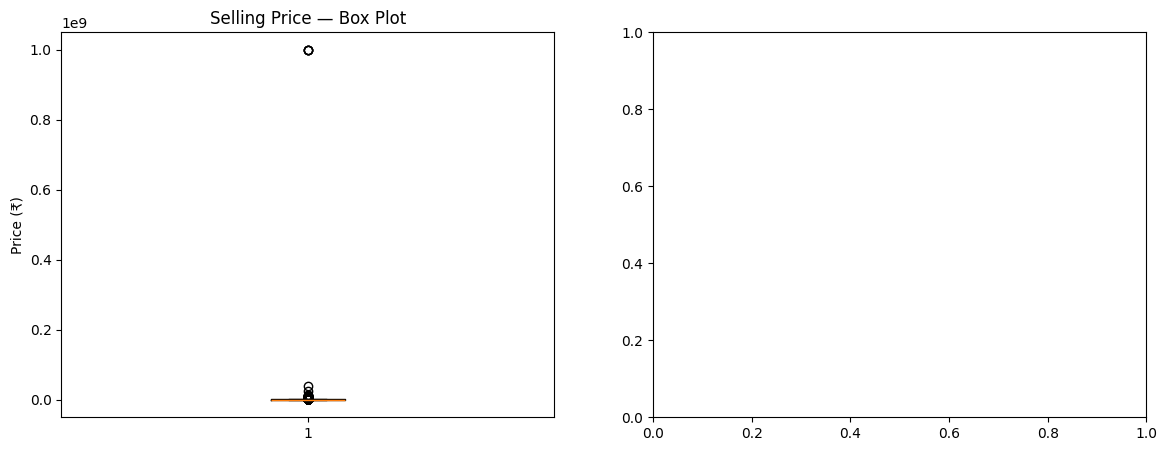

In [ ]:
# Visualize outliers in selling_price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price — Box Plot')
axes[0].set_ylabel('Price (₹)')


In [ ]:
before = len(df)

df = df[df['selling_price'] != 999999999]
df = df[df["selling_price"]>10000]
df = df[df["seats"]>0]

after = len(df)


print(before, after)

15212 15202


In [ ]:
df[df['vehicle_age'] == '15152']

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [ ]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.8700,1461.0000,83.8000,5.0000,575000.0000
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,Cng,Manual,33.5400,998.0000,67.0400,5.0000,435000.0000
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,19.6700,1497.0000,117.6000,5.0000,875000.0000
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,Dealer,Diesel,Manual,15.4000,2179.0000,88.5000,8.0000,925000.0000
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0000,2179.0000,140.0000,7.0000,1175000.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.7700,1248.0000,88.8000,7.0000,665000.0000
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.0900,1248.0000,103.2000,5.0000,249000.0000
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.5100,998.0000,67.0400,5.0000,250000.0000
15659,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6000,1197.0000,81.8600,5.0000,620000.0000


In [ ]:
# Method 1: Simple map (recommended for binary)
df['transmission_type'] = df['transmission_type'].map({'Manual': 0, 'Automatic': 1})

df['transmission_type']


,transmission_type
0,0
1,0
2,0
3,0
4,1
...,...
15656,0
15657,0
15658,0
15659,0


In [ ]:
print(f"Number of columns beofre one hot encoding {df.shape[1]}")

df = pd.get_dummies(df, columns = ['fuel_type', 'seller_type'], drop_first = True)

print(f"Number of columns after one hot encoding {df.shape[1]}")

df

Number of columns beofre one hot encoding 13
Number of columns after one hot encoding 17


,car_name,brand,model,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,Renault Duster,Renault,Duster,7,67647,0,19.8700,1461.0000,83.8000,5.0000,575000.0000,True,False,False,False,False,False
1,Maruti Wagon R,Maruti,Wagon R,3,52000,0,33.5400,998.0000,67.0400,5.0000,435000.0000,False,False,False,False,False,False
2,Honda City,Honda,City,3,48959,0,19.6700,1497.0000,117.6000,5.0000,875000.0000,False,False,False,True,False,False
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,0,15.4000,2179.0000,88.5000,8.0000,925000.0000,True,False,False,False,False,False
4,Mahindra XUV500,Mahindra,XUV500,4,34000,1,16.0000,2179.0000,140.0000,7.0000,1175000.0000,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,0,20.7700,1248.0000,88.8000,7.0000,665000.0000,True,False,False,False,False,False
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,0,16.0900,1248.0000,103.2000,5.0000,249000.0000,False,False,False,True,False,False
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,0,20.5100,998.0000,67.0400,5.0000,250000.0000,False,False,False,True,True,False
15659,Hyundai i20,Hyundai,i20,2,15000,0,18.6000,1197.0000,81.8600,5.0000,620000.0000,False,False,False,True,False,False


In [ ]:
df['brand'].nunique()

32

In [ ]:
df['brand'].value_counts()

,count
brand,
Maruti,4922
Hyundai,2949
Honda,1465
Mahindra,992
Toyota,790
Ford,773
Volkswagen,610
Renault,524
BMW,434


In [ ]:
df

,car_name,brand,model,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,Renault Duster,Renault,Duster,7,67647,0,19.8700,1461.0000,83.8000,5.0000,575000.0000,True,False,False,False,False,False
1,Maruti Wagon R,Maruti,Wagon R,3,52000,0,33.5400,998.0000,67.0400,5.0000,435000.0000,False,False,False,False,False,False
2,Honda City,Honda,City,3,48959,0,19.6700,1497.0000,117.6000,5.0000,875000.0000,False,False,False,True,False,False
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,0,15.4000,2179.0000,88.5000,8.0000,925000.0000,True,False,False,False,False,False
4,Mahindra XUV500,Mahindra,XUV500,4,34000,1,16.0000,2179.0000,140.0000,7.0000,1175000.0000,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,0,20.7700,1248.0000,88.8000,7.0000,665000.0000,True,False,False,False,False,False
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,0,16.0900,1248.0000,103.2000,5.0000,249000.0000,False,False,False,True,False,False
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,0,20.5100,998.0000,67.0400,5.0000,250000.0000,False,False,False,True,True,False
15659,Hyundai i20,Hyundai,i20,2,15000,0,18.6000,1197.0000,81.8600,5.0000,620000.0000,False,False,False,True,False,False


In [ ]:
# Step 1: See the distribution of brands
brand_counts = df['brand'].value_counts()
print("Brand distribution:")
print(brand_counts)
print(f"\nBrands with < 100 cars: {(brand_counts < 100).sum()}")

Brand distribution:
brand
Maruti           4922
Hyundai          2949
Honda            1465
Mahindra          992
Toyota            790
Ford              773
Volkswagen        610
Renault           524
BMW               434
Tata              424
Mercedes-Benz     331
Skoda             331
Audi              190
Datsun            168
Jaguar             59
Land Rover         50
Jeep               42
Kia                32
Porsche            22
Volvo              20
MG                 19
Mini               17
Nissan             10
Lexus               9
Isuzu               8
Bentley             3
ISUZU               2
Maserati            2
Ferrari             1
Mercedes-AMG        1
Force               1
Rolls-Royce         1
Name: count, dtype: int64

Brands with < 100 cars: 18


In [ ]:
# Step 2: Group rare brands (< 100 cars) into "Other"
rare_brands = brand_counts[brand_counts < 100].index.tolist()
print(f"Grouping {len(rare_brands)} rare brands into 'Other': {rare_brands}")

df['brand'] = df['brand'].replace(rare_brands, 'Other')

print(f"\nBrand distribution after grouping:")
print(df['brand'].value_counts())

Grouping 18 rare brands into 'Other': ['Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche', 'Volvo', 'MG', 'Mini', 'Nissan', 'Lexus', 'Isuzu', 'Bentley', 'ISUZU', 'Maserati', 'Ferrari', 'Mercedes-AMG', 'Force', 'Rolls-Royce']

Brand distribution after grouping:
brand
Maruti           4922
Hyundai          2949
Honda            1465
Mahindra          992
Toyota            790
Ford              773
Volkswagen        610
Renault           524
BMW               434
Tata              424
Skoda             331
Mercedes-Benz     331
Other             299
Audi              190
Datsun            168
Name: count, dtype: int64


In [ ]:
# Step 2: Group rare brands (< 100 cars) into "Other"
rare_brands = brand_counts[brand_counts < 100].index.tolist()
print(f"Grouping {len(rare_brands)} rare brands into 'Other': {rare_brands}")

df['brand'] = df['brand'].replace(rare_brands, 'Other')

print(f"\nBrand distribution after grouping:")
print(df['brand'].value_counts())

Grouping 18 rare brands into 'Other': ['Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche', 'Volvo', 'MG', 'Mini', 'Nissan', 'Lexus', 'Isuzu', 'Bentley', 'ISUZU', 'Maserati', 'Ferrari', 'Mercedes-AMG', 'Force', 'Rolls-Royce']

Brand distribution after grouping:
brand
Maruti           4922
Hyundai          2949
Honda            1465
Mahindra          992
Toyota            790
Ford              773
Volkswagen        610
Renault           524
BMW               434
Tata              424
Skoda             331
Mercedes-Benz     331
Other             299
Audi              190
Datsun            168
Name: count, dtype: int64


In [ ]:
# Step 3: One-hot encode the cleaned brand column
df = pd.get_dummies(df, columns=['brand'], drop_first=True)

print(f"Total columns after all encoding: {df.shape[1]}")
brand_cols = [col for col in df.columns if 'brand_' in col]
print(f"Brand columns created: {len(brand_cols)}")

Total columns after all encoding: 30
Brand columns created: 14


In [ ]:
df

,car_name,model,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,Renault Duster,Duster,7,67647,0,19.8700,1461.0000,83.8000,5.0000,575000.0000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,Maruti Wagon R,Wagon R,3,52000,0,33.5400,998.0000,67.0400,5.0000,435000.0000,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,Honda City,City,3,48959,0,19.6700,1497.0000,117.6000,5.0000,875000.0000,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,Mahindra Scorpio,Scorpio,6,82000,0,15.4000,2179.0000,88.5000,8.0000,925000.0000,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,Mahindra XUV500,XUV500,4,34000,1,16.0000,2179.0000,140.0000,7.0000,1175000.0000,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Ertiga,7,127731,0,20.7700,1248.0000,88.8000,7.0000,665000.0000,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
15657,Volkswagen Vento,Vento,11,59000,0,16.0900,1248.0000,103.2000,5.0000,249000.0000,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
15658,Maruti Wagon R,Wagon R,7,20000,0,20.5100,998.0000,67.0400,5.0000,250000.0000,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
15659,Hyundai i20,i20,2,15000,0,18.6000,1197.0000,81.8600,5.0000,620000.0000,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
df = df.drop(columns=['car_name', 'model'], errors='ignore')

print(f"Final shape after encoding and dropping: {df.shape}")
print(f"\nAll columns:")
print(df.columns.tolist())

Final shape after encoding and dropping: (15202, 28)

All columns:
['vehicle_age', 'km_driven', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_Lpg', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'brand_BMW', 'brand_Datsun', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Other', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']


In [ ]:
df

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,7,67647,0,19.8700,1461.0000,83.8000,5.0000,575000.0000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,3,52000,0,33.5400,998.0000,67.0400,5.0000,435000.0000,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,3,48959,0,19.6700,1497.0000,117.6000,5.0000,875000.0000,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,6,82000,0,15.4000,2179.0000,88.5000,8.0000,925000.0000,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,4,34000,1,16.0000,2179.0000,140.0000,7.0000,1175000.0000,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,7,127731,0,20.7700,1248.0000,88.8000,7.0000,665000.0000,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
15657,11,59000,0,16.0900,1248.0000,103.2000,5.0000,249000.0000,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
15658,7,20000,0,20.5100,998.0000,67.0400,5.0000,250000.0000,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
15659,2,15000,0,18.6000,1197.0000,81.8600,5.0000,620000.0000,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Step 1: Separate features (X) and target (y)
X = df.drop(columns=['selling_price'])
y = df['selling_price']

In [ ]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (15202, 27)
Target shape: (15202,)


In [ ]:
# Step 2: Split FIRST (before any scaling!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Train set: 12161 rows
Test set: 3041 rows


In [ ]:
X_train

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
4545,3,90000,0,24.3000,1248.0000,88.5000,5.0000,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
14512,9,100000,0,22.3200,1582.0000,126.3000,5.0000,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
11050,9,89000,1,19.6700,1248.0000,187.7000,5.0000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
9106,6,43719,0,22.3000,799.0000,53.2600,5.0000,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
10400,5,57246,0,25.4700,1248.0000,88.5000,7.0000,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5282,4,90000,0,20.3400,1248.0000,103.2000,5.0000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
13801,8,75000,0,20.5400,1598.0000,103.6000,5.0000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
5483,13,40000,0,19.7000,796.0000,46.3000,5.0000,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
871,8,70000,0,24.0000,1120.0000,70.0000,5.0000,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [ ]:
X_train

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
4545,-1.0086,0.8067,0,1.1713,-0.4158,-0.2729,-0.3931,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
14512,0.9904,1.0401,0,0.6691,0.2759,0.6457,-0.3931,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
11050,0.9904,0.7834,1,-0.0029,-0.4158,2.1379,-0.3931,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
9106,-0.0091,-0.2735,0,0.6641,-1.3458,-1.1293,-0.3931,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
10400,-0.3422,0.0422,0,1.4680,-0.4158,-0.2729,2.1375,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5282,-0.6754,0.8067,0,0.1670,-0.4158,0.0843,-0.3931,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
13801,0.6573,0.4566,0,0.2177,0.3091,0.0941,-0.3931,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
5483,2.3231,-0.3603,0,0.0047,-1.3520,-1.2985,-0.3931,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
871,0.6573,0.3399,0,1.0952,-0.6809,-0.7225,-0.3931,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
X_test

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
575,-1.0086,-0.4770,0,0.1568,-0.5173,-0.3823,-0.3931,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
11877,-1.0086,0.3633,0,-0.0029,0.2759,0.6433,-0.3931,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
15362,0.6573,0.5227,0,0.8162,-0.4158,-0.6253,-0.3931,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4389,-1.0086,-0.7805,1,-0.6268,-0.5214,0.0941,-0.3931,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
12290,-0.3422,0.3399,0,-1.5221,1.9556,1.1683,3.4027,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12425,0.3241,0.6900,0,-0.0207,0.0253,0.2119,-0.3931,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4770,-0.0091,0.1065,0,-0.5710,-0.1093,0.1402,-0.3931,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
10194,-0.6754,-0.4770,0,0.5347,-0.9336,-0.7942,-0.3931,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
13371,-1.0086,-0.2232,0,1.7546,-0.9336,-0.2729,-0.3931,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
